# Troisième étape de modélisation: deuxième limite - Questions 1.2.5

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist
import pandas as pd

rng = np.random.default_rng(42)

from helpers.helpers_QRNIID import *
from helpers.helpers_QR2LIM import *

rng = np.random.default_rng(42)


## 1. Deuxieme limite constante

On ajoute les deuxiemes limites `N^{+2}` et `N^{-2}`. Dans cette premiere sous-question, leurs intensites d'ajout et de retrait sont constantes, comme dans le modele Poisson de la question 1.2.3. Les premieres limites `N^{+1}` et `N^{-1}` gardent la dynamique Hawkes couplee de la question 1.2.4, ce qui justifie l'utilisation des mêmes paramètres.

Le point important est que, dans cette sous-question, les deuxiemes limites n'influencent pas les premieres. On peut donc separer exactement le probleme en deux blocs independants :

1. simuler les premieres limites Hawkes jusqu'au premier temps d'epuisement

```text
tau = min(tau_{+1}, tau_{-1}),
tau_{+1} = inf { t >= 0 : N^{+1}_t = 0 },
tau_{-1} = inf { t >= 0 : N^{-1}_t = 0 };
```

2. simuler independamment `N^{+2}` sur l'intervalle aleatoire `[0, tau]` avec des taux constants.

Dans le code precedent, `bid` correspond a `+1` et `ask` a `-1`. On estime alors deux lois empiriques :

```text
N^{+2}_tau | { tau = tau_{+1} }
N^{+2}_tau | { tau = tau_{-1} }
```

La deuxieme limite est une taille de file : son taux de retrait est constant lorsqu'elle est strictement positive, et vaut zero lorsqu'elle est deja vide. Autrement dit, le taux de retrait constant est une intensite de base, pas une permission de passer en taille negative.

Comme `N^{+2}` est ici independant des premieres limites, et comme le modele est symetrique entre `+1` et `-1`, les deux distributions conditionnelles doivent etre tres proches. Cette premiere sous-question sert donc de reference neutre avant d'ajouter le feedback de la question 1.2.5.2.

In [2]:
# Same parameters from QRNIID.ipynb
q0 = 10
mu_plus = 1.0
mu_minus = 1.1
alpha = 0.50
beta = 0.50
lambda_floor = 1e-8
gamma_cross = 1.0

eta = alpha / beta
lambda_minus_theory = theoretical_stationary_lambda_minus(mu_plus, mu_minus, alpha, beta)

print(f"eta = alpha / beta = {eta:.3f}")
print(f"Theoretical stationary E[lambda_minus] = {lambda_minus_theory:.4f}")
print(f"gamma_cross = {gamma_cross:.2f}")

eta = alpha / beta = 1.000
Theoretical stationary E[lambda_minus] = 1.0500
gamma_cross = 1.00


In [3]:
# Paramètres de la seconde limite à taux constant.
# Nous les maintenons proches des taux moyens de Hawkes à une limite 
# afin que l'échelle soit comparable à celle de la section précédente.
q2_0 = q0
lambda_second_add = mu_plus
lambda_second_remove = lambda_minus_theory

print(f"Initial second-limit size q2_0 = {q2_0}")
print(f"Second-limit addition rate = {lambda_second_add:.3f}")
print(f"Second-limit removal rate  = {lambda_second_remove:.3f}")

Initial second-limit size q2_0 = 10
Second-limit addition rate = 1.000
Second-limit removal rate  = 1.050


In [4]:
n_second_limit_samples = 5_000
second_limit_constant_samples = sample_second_limit_conditionals_constant(
    n_samples=n_second_limit_samples,
    q1_0=q0,
    q2_0=q2_0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    lambda_second_add=lambda_second_add,
    lambda_second_remove=lambda_second_remove,
    gamma_cross=gamma_cross,
    rng=rng,
    t_max=10_000.0,
)

first_empty = second_limit_constant_samples["first_empty"]
hit_zero = second_limit_constant_samples["hit_zero"]
plus2_at_tau = second_limit_constant_samples["plus2_at_tau"]

plus1_empty_mask = hit_zero & (first_empty == "plus1")
minus1_empty_mask = hit_zero & (first_empty == "minus1")

plus2_given_plus1_empty = plus2_at_tau[plus1_empty_mask]
plus2_given_minus1_empty = plus2_at_tau[minus1_empty_mask]

print(f"Number of simulations = {n_second_limit_samples}")
print(f"Hit probability before t_max = {hit_zero.mean():.4f}")
print(f"P(tau = tau_{{+1}}) = {plus1_empty_mask.mean():.4f}")
print(f"P(tau = tau_{{-1}}) = {minus1_empty_mask.mean():.4f}")
print()
print("Conditional distribution summaries for N^{+2}_tau")
print("Condition                         Count    Mean     Std     Q05     Q50     Q95")
print("----------------------------------------------------------------------------")

for label, values in [
    ("N^{+1}_tau = 0", plus2_given_plus1_empty),
    ("N^{-1}_tau = 0", plus2_given_minus1_empty),
]:
    q05, q50, q95 = np.quantile(values, [0.05, 0.50, 0.95])
    print(f"{label:<31} {len(values):5d}  {values.mean():7.3f} {values.std(ddof=1):7.3f} {q05:7.1f} {q50:7.1f} {q95:7.1f}")

ks_distance = empirical_cdf_distance(plus2_given_plus1_empty, plus2_given_minus1_empty)
mean_gap = plus2_given_plus1_empty.mean() - plus2_given_minus1_empty.mean()

print()
print(f"Empirical CDF distance between the two conditionals = {ks_distance:.4f}")
print(f"Mean gap = {mean_gap:.4f}")

Number of simulations = 5000
Hit probability before t_max = 1.0000
P(tau = tau_{+1}) = 0.4988
P(tau = tau_{-1}) = 0.5012

Conditional distribution summaries for N^{+2}_tau
Condition                         Count    Mean     Std     Q05     Q50     Q95
----------------------------------------------------------------------------
N^{+1}_tau = 0                   2494   10.004   7.790     0.0     9.0    24.0
N^{-1}_tau = 0                   2506   10.314   7.853     0.0     9.0    25.0

Empirical CDF distance between the two conditionals = 0.0238
Mean gap = -0.3100


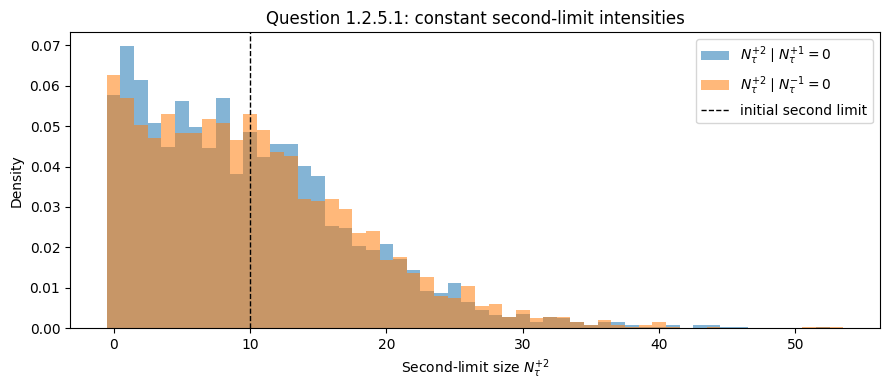

In [5]:
bins = np.arange(
    min(plus2_at_tau.min(), q2_0) - 0.5,
    max(plus2_at_tau.max(), q2_0) + 1.5,
    1.0,
)

plt.figure(figsize=(9, 4))
plt.hist(
    plus2_given_plus1_empty,
    bins=bins,
    density=True,
    alpha=0.55,
    label=r"$N^{+2}_\tau \mid N^{+1}_\tau = 0$",
)
plt.hist(
    plus2_given_minus1_empty,
    bins=bins,
    density=True,
    alpha=0.55,
    label=r"$N^{+2}_\tau \mid N^{-1}_\tau = 0$",
)
plt.axvline(q2_0, color="black", linestyle="--", linewidth=1, label="initial second limit")
plt.xlabel(r"Second-limit size $N^{+2}_\tau$")
plt.ylabel("Density")
plt.title("Question 1.2.5.1: constant second-limit intensities")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Deuxième limite réactive

On introduit une dynamique réactive pour la deuxième limite. Pour la deuxième limite côté bid, on considère une intensité d'ajout de la forme

$$
\lambda^{+}_{+2}(t)
=
\mu^{+}_{+2}
+
Z_{+2}(t),
$$

où

$$
Z_{+2}(t)
=
\int_{s<t} a e^{-b(t-s)}\, dN^{-}_{+1}(s).
$$

Ainsi, chaque retrait sur la première limite $+1$ ajoute une impulsion de taille $a$ à la mémoire $Z_{+2}$, puis cette mémoire décroît exponentiellement avec vitesse $b$. En notation différentielle, cela revient à écrire

$$
dZ_{+2}(t)
=
-b Z_{+2}(t)\,dt
+
a\,dN^{-}_{+1}(t).
$$

Le paramètre $a$ contrôle donc l'intensité de la réaction de la deuxième limite aux retraits de la première limite, tandis que $b$ contrôle la vitesse d'oubli de cette réaction.

In [6]:
# Question 1.2.5.2 : deuxième limite réactive

a_second = 0.25
b_second = beta

n_second_limit_samples = 5_000

second_limit_reactive_samples = sample_second_limit_conditionals_reactive(
    n_samples=n_second_limit_samples,
    q1_0=q0,
    q2_0=q2_0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    lambda_second_add=lambda_second_add,
    lambda_second_remove=lambda_second_remove,
    a_second=a_second,
    b_second=b_second,
    gamma_cross=gamma_cross,
    rng=rng,
    t_max=10_000.0,
)

first_empty = second_limit_reactive_samples["first_empty"]
hit_zero = second_limit_reactive_samples["hit_zero"]
plus2_at_tau = second_limit_reactive_samples["plus2_at_tau"]

plus1_empty_mask = hit_zero & (first_empty == "plus1")
minus1_empty_mask = hit_zero & (first_empty == "minus1")

plus2_given_plus1_empty = plus2_at_tau[plus1_empty_mask]
plus2_given_minus1_empty = plus2_at_tau[minus1_empty_mask]

print(f"a_second = {a_second:.3f}")
print(f"b_second = {b_second:.3f}")
print(f"eta_second = a_second / b_second = {a_second / b_second:.3f}")
print()
print(f"Number of simulations = {n_second_limit_samples}")
print(f"Hit probability before t_max = {hit_zero.mean():.4f}")
print(f"P(tau = tau_{{+1}}) = {plus1_empty_mask.mean():.4f}")
print(f"P(tau = tau_{{-1}}) = {minus1_empty_mask.mean():.4f}")
print()
print("Conditional distribution summaries for N^{+2}_tau")
print("Condition                         Count    Mean     Std     Q05     Q50     Q95")
print("----------------------------------------------------------------------------")

for label, values in [
    ("N^{+1}_tau = 0", plus2_given_plus1_empty),
    ("N^{-1}_tau = 0", plus2_given_minus1_empty),
]:
    q05, q50, q95 = np.quantile(values, [0.05, 0.50, 0.95])
    print(
        f"{label:<31} {len(values):5d}  "
        f"{values.mean():7.3f} {values.std(ddof=1):7.3f} "
        f"{q05:7.1f} {q50:7.1f} {q95:7.1f}"
    )

ks_distance = empirical_cdf_distance(plus2_given_plus1_empty, plus2_given_minus1_empty)
mean_gap = plus2_given_plus1_empty.mean() - plus2_given_minus1_empty.mean()

print()
print(f"Empirical CDF distance between the two conditionals = {ks_distance:.4f}")
print(f"Mean gap = {mean_gap:.4f}")

a_second = 0.250
b_second = 0.500
eta_second = a_second / b_second = 0.500

Number of simulations = 5000
Hit probability before t_max = 1.0000
P(tau = tau_{+1}) = 0.4984
P(tau = tau_{-1}) = 0.5016

Conditional distribution summaries for N^{+2}_tau
Condition                         Count    Mean     Std     Q05     Q50     Q95
----------------------------------------------------------------------------
N^{+1}_tau = 0                   2492   38.978  25.539    12.0    33.0    87.4
N^{-1}_tau = 0                   2508   34.828  24.097     9.0    29.0    82.0

Empirical CDF distance between the two conditionals = 0.0911
Mean gap = 4.1506


La simulation suit toujours une structure conditionnelle. On commence par simuler les deux premières limites $N^{+1}$ et $N^{-1}$ avec la dynamique Hawkes couplée de la question 1.2.4, jusqu'au premier temps d'épuisement

$$
\tau = \tau_{+1} \wedge \tau_{-1}.
$$

Ensuite, conditionnellement à cette trajectoire des premières limites, on simule la deuxième limite $N^{+2}$ sur l'intervalle aléatoire $[0,\tau]$. La différence avec la question 1.2.5.1 est que l'intensité d'ajout de $N^{+2}$ n'est plus constante : elle dépend des temps de retrait observés sur $N^{+1}$.

Dans le code, la variable `driver_removal_times` contient précisément les instants de retrait de la première limite $+1$. À chacun de ces instants, la mémoire $Z_{+2}$ est augmentée de $a$. Entre deux événements, elle est multipliée par

$$
e^{-b\Delta t}.
$$

On compare ensuite les deux lois conditionnelles suivantes :

$$
N^{+2}_{\tau}\mid \{N^{+1}_{\tau}=0\},
$$

et

$$
N^{+2}_{\tau}\mid \{N^{-1}_{\tau}=0\}.
$$

La première condition correspond au cas où la première limite du même côté que $N^{+2}$ est consommée. La deuxième condition sert de référence : elle correspond au cas où c'est la première limite opposée qui disparaît.

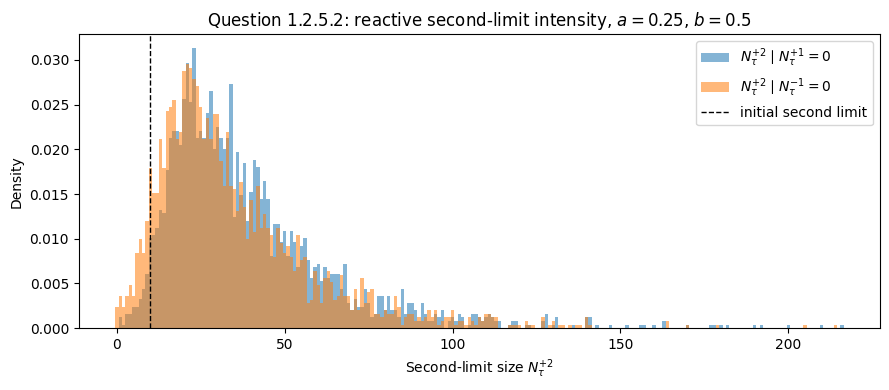

In [7]:
bins = np.arange(
    min(plus2_at_tau.min(), q2_0) - 0.5,
    max(plus2_at_tau.max(), q2_0) + 1.5,
    1.0,
)

plt.figure(figsize=(9, 4))

plt.hist(
    plus2_given_plus1_empty,
    bins=bins,
    density=True,
    alpha=0.55,
    label=r"$N^{+2}_\tau \mid N^{+1}_\tau = 0$",
)

plt.hist(
    plus2_given_minus1_empty,
    bins=bins,
    density=True,
    alpha=0.55,
    label=r"$N^{+2}_\tau \mid N^{-1}_\tau = 0$",
)

plt.axvline(q2_0, color="black", linestyle="--", linewidth=1, label="initial second limit")

plt.xlabel(r"Second-limit size $N^{+2}_\tau$")
plt.ylabel("Density")
plt.title(
    rf"Question 1.2.5.2: reactive second-limit intensity, "
    rf"$a={a_second}$, $b={b_second}$"
)
plt.legend()
plt.tight_layout()
plt.show()

Le graphique compare les distributions empiriques de $N^{+2}_{\tau}$ selon la première limite qui atteint zéro. Dans le cas réactif, on s'attend à observer une différence plus marquée que dans le modèle à intensités constantes.

En effet, lorsque $N^{+1}$ atteint zéro, cela signifie généralement qu'il y a eu une séquence importante de retraits sur cette première limite. Ces retraits augmentent directement la mémoire $Z_{+2}$, donc l'intensité d'ajout de la deuxième limite $N^{+2}$. On s'attend donc à obtenir

$$
\mathbb{E}\left[N^{+2}_{\tau}\mid N^{+1}_{\tau}=0\right]
>
\mathbb{E}\left[N^{+2}_{\tau}\mid N^{-1}_{\tau}=0\right].
$$

À l'inverse, lorsque $N^{-1}$ atteint zéro, les retraits responsables de cet épuisement concernent principalement l'autre côté du carnet. Ils n'alimentent pas directement la mémoire de $N^{+2}$. La deuxième limite $+2$ reste donc plus proche de sa dynamique de base.

L'écart entre les deux distributions donne ainsi une mesure de la résilience du carnet du côté $+2$ après la consommation de la première limite $+1$.

## Étude de sensibilité en fonction de $a$

Le paramètre $a$ mesure l'ampleur de la réaction de la deuxième limite aux retraits observés sur la première limite. Pour étudier son effet, on fixe le paramètre de décroissance $b$, puis on répète les simulations pour plusieurs valeurs de $a$.

Le rapport

$$
\eta_2 = \frac{a}{b}
$$

a une interprétation importante : il correspond à la masse totale du noyau exponentiel

$$
\int_0^{+\infty} a e^{-bt}\,dt = \frac{a}{b}.
$$

Ainsi, $\eta_2$ mesure l'effet cumulé moyen d'un retrait de la première limite sur l'intensité d'ajout de la deuxième limite.

Lorsque $a=0$, on retrouve le modèle de la question 1.2.5.1 : la deuxième limite n'est pas réactive et son intensité d'ajout reste constante. Lorsque $a$ augmente, les retraits sur $N^{+1}$ produisent des impulsions plus fortes sur l'intensité d'ajout de $N^{+2}$. On s'attend donc à voir augmenter la moyenne conditionnelle

$$
\mathbb{E}\left[N^{+2}_{\tau}\mid N^{+1}_{\tau}=0\right].
$$

En revanche, la quantité

$$
\mathbb{E}\left[N^{+2}_{\tau}\mid N^{-1}_{\tau}=0\right]
$$

devrait être beaucoup moins sensible à $a$, car l'épuisement de $N^{-1}$ n'est pas directement causé par les retraits de $N^{+1}$.

In [8]:
a_grid = [0.0, 0.10, 0.25, 0.50, 0.75, 0.95, 2.0, 3.0, 4.0]
b_second = beta

summary_rows = []

for a_second in a_grid:
    samples = sample_second_limit_conditionals_reactive(
        n_samples=3_000,
        q1_0=q0,
        q2_0=q2_0,
        mu_plus=mu_plus,
        mu_minus=mu_minus,
        alpha=alpha,
        beta=beta,
        lambda_second_add=lambda_second_add,
        lambda_second_remove=lambda_second_remove,
        a_second=a_second,
        b_second=b_second,
        gamma_cross=gamma_cross,
        rng=rng,
        t_max=10_000.0,
    )

    first_empty = samples["first_empty"]
    hit_zero = samples["hit_zero"]
    plus2_at_tau = samples["plus2_at_tau"]

    plus1_empty_mask = hit_zero & (first_empty == "plus1")
    minus1_empty_mask = hit_zero & (first_empty == "minus1")

    values_plus1 = plus2_at_tau[plus1_empty_mask]
    values_minus1 = plus2_at_tau[minus1_empty_mask]

    summary_rows.append({
        "a": a_second,
        "eta=a/b": a_second / b_second,
        "mean_plus2_given_plus1_empty": values_plus1.mean(),
        "mean_plus2_given_minus1_empty": values_minus1.mean(),
        "mean_gap": values_plus1.mean() - values_minus1.mean(),
        "ks_distance": empirical_cdf_distance(values_plus1, values_minus1),
        "q05_plus1": np.quantile(values_plus1, 0.05),
        "q50_plus1": np.quantile(values_plus1, 0.50),
        "q95_plus1": np.quantile(values_plus1, 0.95),
    })

In [9]:
sensitivity_df = pd.DataFrame(summary_rows)
sensitivity_df

,a,eta=a/b,mean_plus2_given_plus1_empty,mean_plus2_given_minus1_empty,mean_gap,ks_distance,q05_plus1,q50_plus1,q95_plus1
0,0.00,0.0,9.884744,9.715143,0.169600,0.025539,0.00,8.0,25.00
1,0.10,0.2,20.841015,19.197605,1.643411,0.063258,4.00,18.0,49.00
2,0.25,0.5,39.697674,36.681605,3.016069,0.082992,11.00,33.0,90.00
3,0.50,1.0,71.234015,63.417397,7.816617,0.085560,22.00,57.0,163.00
4,0.75,1.5,103.876543,91.470817,12.405726,0.097791,32.00,83.0,248.00
5,0.95,1.9,130.168675,113.232404,16.936271,0.110279,39.00,105.0,301.35
6,2.00,4.0,259.907023,227.696346,32.210678,0.123095,70.70,210.0,616.50
7,3.00,6.0,383.540830,345.001992,38.538838,0.100551,102.65,311.5,938.10
8,4.00,8.0,527.317440,456.818924,70.498515,0.104383,145.00,419.0,1295.50


Le tableau résume l'effet du paramètre $a$ sur les lois conditionnelles de $N^{+2}_{\tau}$. On observe notamment trois quantités :

1. la moyenne conditionnelle sachant que $N^{+1}$ est consommée ;
2. la moyenne conditionnelle sachant que $N^{-1}$ est consommée ;
3. l'écart entre ces deux moyennes.

L'écart

$$
\Delta(a)
=
\mathbb{E}\left[N^{+2}_{\tau}\mid N^{+1}_{\tau}=0\right]
-
\mathbb{E}\left[N^{+2}_{\tau}\mid N^{-1}_{\tau}=0\right]
$$

est une mesure simple de l'effet réactif introduit dans le modèle. Si $\Delta(a)$ augmente avec $a$, cela signifie que la deuxième limite se renforce davantage lorsque la première limite du même côté est consommée.

On calcule aussi une distance entre fonctions de répartition empiriques, notée ici `ks_distance`. Cette quantité mesure l'écart global entre les deux distributions conditionnelles, et pas seulement l'écart entre leurs moyennes.

### Remarque:

Pour $a=0$, la dynamique réactive se réduit au cas à intensité constante, puisque les retraits de la première limite n'ajoutent plus d'impulsion à l'intensité d'ajout de la deuxième limite. Théoriquement, par symétrie du modèle, les deux moyennes conditionnelles devraient donc être égales.

Le léger écart observé entre les deux moyennes est interprété comme une fluctuation de Monte Carlo. Il peut aussi provenir d'une légère différence empirique entre les distributions de $\tau$ conditionnellement à l'épuisement de $N^{+1}$ ou de $N^{-1}$. Lorsque le nombre de simulations augmente, cet écart doit diminuer et devenir non significatif par rapport à son intervalle de confiance.

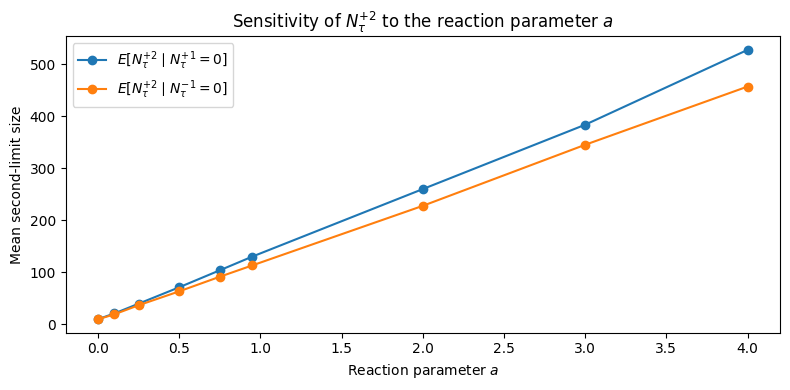

In [10]:
plt.figure(figsize=(8, 4))

plt.plot(
    sensitivity_df["a"],
    sensitivity_df["mean_plus2_given_plus1_empty"],
    marker="o",
    label=r"$E[N^{+2}_\tau \mid N^{+1}_\tau = 0]$",
)

plt.plot(
    sensitivity_df["a"],
    sensitivity_df["mean_plus2_given_minus1_empty"],
    marker="o",
    label=r"$E[N^{+2}_\tau \mid N^{-1}_\tau = 0]$",
)

plt.xlabel(r"Reaction parameter $a$")
plt.ylabel(r"Mean second-limit size")
plt.title(r"Sensitivity of $N^{+2}_\tau$ to the reaction parameter $a$")
plt.legend()
plt.tight_layout()
plt.show()

Le graphique montre l'évolution des moyennes conditionnelles lorsque le paramètre $a$ varie. La courbe associée à

$$
\mathbb{E}\left[N^{+2}_{\tau}\mid N^{+1}_{\tau}=0\right]
$$

devrait croître avec $a$, car une valeur plus grande de $a$ amplifie l'effet des retraits de $N^{+1}$ sur les ajouts de $N^{+2}$.

La courbe associée à

$$
\mathbb{E}\left[N^{+2}_{\tau}\mid N^{-1}_{\tau}=0\right]
$$

sert de comparaison. Si elle varie peu avec $a$, cela confirme que l'effet réactif est bien localisé du côté concerné par la consommation de la première limite.

Cette expérience met donc en évidence un phénomène de résilience asymétrique : après une consommation de la première limite $+1$, la deuxième limite $+2$ peut être plus fournie, car elle a été alimentée par les retraits récents de la première limite.

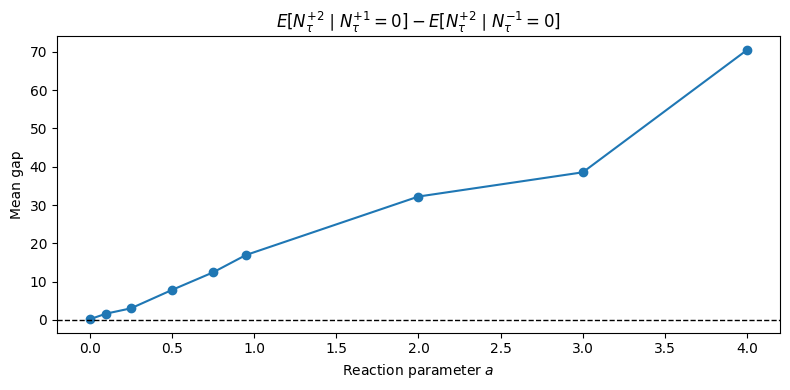

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(
    sensitivity_df["a"],
    sensitivity_df["mean_gap"],
    marker="o",
)

plt.axhline(0.0, color="black", linestyle="--", linewidth=1)

plt.xlabel(r"Reaction parameter $a$")
plt.ylabel(r"Mean gap")
plt.title(
    r"$E[N^{+2}_\tau \mid N^{+1}_\tau = 0] - E[N^{+2}_\tau \mid N^{-1}_\tau = 0]$"
)
plt.tight_layout()
plt.show()

L'écart moyen $\Delta(a)$ permet de synthétiser l'effet du paramètre $a$. Pour $a=0$, la deuxième limite n'est pas réactive : les deux distributions conditionnelles doivent donc être proches, à des fluctuations de Monte Carlo près. Lorsque $a$ augmente, les retraits de la première limite $+1$ génèrent davantage d'ajouts sur $N^{+2}$, ce qui augmente la taille moyenne de la deuxième limite dans le scénario où $N^{+1}$ est consommée.

Une valeur positive et croissante de $\Delta(a)$ confirme donc que la dynamique implémentée capture l'effet attendu : la deuxième limite du même côté devient plus liquide après une séquence de retraits sur la première limite.

### Interprétation en termes d'événements rares

La consommation totale d'une première limite est un événement important dans un carnet d'ordres, car elle peut provoquer un déplacement du meilleur prix. Cependant, l'effet réel sur le carnet dépend aussi de la taille de la deuxième limite au moment où la première disparaît.

Dans cette perspective, la quantité $N^{+2}_{\tau}$ mesure la liquidité disponible immédiatement derrière la première limite consommée. Un événement particulièrement défavorable est donc

$$
\{N^{+1}_{\tau}=0\}
\cap
\{N^{+2}_{\tau} \leq h\},
$$

où $h$ est un seuil de faible liquidité. Cet événement correspond à une situation dans laquelle la première limite est consommée et la deuxième limite est peu fournie. Le carnet est alors peu résilient.

Pour l'instant, les simulations de Monte Carlo directes suffisent pour estimer les distributions conditionnelles demandées dans la question 1.2.5.2. Les méthodes spécifiques aux événements rares deviendraient surtout utiles si l'on cherchait à estimer des probabilités très faibles, par exemple

$$
\mathbb{P}\left(
N^{+1}_{\tau}=0
\ \text{et}\
N^{+2}_{\tau}\leq h
\right),
$$

avec un seuil $h$ petit ou des conditions initiales plus grandes. Dans ce cas, des méthodes comme l'échantillonnage préférentiel ou le splitting pourraient être utilisées pour augmenter le nombre de trajectoires atteignant la zone rare.